In [1]:
import struct
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage import feature
import re
import matplotlib.gridspec as gridspec

def plot_x_dot_fits(x_test, optimizer, dt, n_models,r):
    model_x_dot_store=[]
    plt.figure(figsize=(10, 5))
    gs = gridspec.GridSpec(r, n_models)
    gs.update(wspace=0.0, hspace=0.0) # set the spacing between axes. 
    for j in range(n_models):
        optimizer.coef_ = np.asarray(optimizer.history_)[j, :, :]

        # Predict derivatives using the learned model
        x_dot_test_predicted = model.predict(x_test)  
        model_x_dot_store.append(x_dot_test_predicted)
        # Compute derivatives with a finite difference method, for comparison
        x_dot_test_computed = model.differentiate(x_test, t=dt)

        for i in range(r):
            plt.subplot(gs[i, j])
            plt.plot(t_test, x_dot_test_computed[:, i],
                        'k', label='numerical derivative')
            plt.plot(t_test, x_dot_test_predicted[:, i],
                        'r', label='model prediction')
            if j == 0:
                plt.ylabel('$\dot ' + pod_names[i] + r'$', fontsize=20)
            if i == 0:
                plt.title('MSE = %.0f' % model.score(x_test, 
                                                     t=dt, 
                                                     metric=mean_squared_error), 
                          fontsize=16)
            plt.xlabel('Iteration ' + str(j), fontsize=16)
            plt.xticks(fontsize=18)
            plt.yticks(fontsize=18)
            ax = plt.gca()
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            plt.grid(True)

        model.print()     
        print('Model ' + str(j) + ', MSE: %f' % model.score(x_test, 
                                                            t=dt, 
                                                            metric=mean_squared_error))
    ax.set_yticklabels([])
    plt.show()
    return  model_x_dot_store

    
def plot_x_fits(x_test, t_test, optimizer, n_models,r):
    model_x_store=[]
    plt.figure(figsize=(10, 5))
    gs = gridspec.GridSpec(r, n_models)
    gs.update(wspace=0.0, hspace=0.0) 
    for j in range(n_models):
        optimizer.coef_ = np.asarray(optimizer.history_)[j, :, :]

        # Simulate dynamic system with the identified model
        # Some of these models may diverge, so need to use odeint 
        # (which just gives a warning)
        # rather than the default solve_ivp, which crashes with an error.
        x_test_sim = model.simulate(x_test[0, :], t_test, integrator='odeint')
        model_x_store.append( x_test_sim)
        for i in range(r):
            plt.subplot(gs[i, j])
            plt.plot(t_test, x_test[:, i]/np.max(x_test[:, i]), 'k', label='test trajectory')
            if np.max(np.abs(x_test_sim[:, i])) < 1000:  # check for instability
                plt.plot(t_test, x_test_sim[:, i]/np.max(x_test_sim[:, i]), 'r', label='model prediction')
            if j == 0:
                plt.ylabel(pod_names[i], fontsize=20)
            if i == 0:
                plt.title('MSE = %.0f' % model.score(x_test, 
                                                     t=dt, 
                                                     metric=mean_squared_error), 
                          fontsize=16)
            plt.xlabel('Iteration ' + str(j), fontsize=16)
            plt.xticks(fontsize=18)
            plt.yticks(fontsize=18)
            ax = plt.gca()
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            plt.grid(True)
   
        print('Model ' + str(j) + ', MSE: %f' % model.score(x_test, 
                                                            t=dt, 
                                                            metric=mean_squared_error))
    ax.set_yticklabels([])
    plt.show()
    return  model_x_store


def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='valid')


##### Calculate Perimeter ###################
def calculate_perimeter(radius, angles):
    
    # Ensure the inputs are numpy arrays
    radius = np.array(radius)
    angles = np.array(angles)
    
    # Calculate the differences in radius and angles
    delta_r = np.diff(radius)
    delta_theta = np.diff(angles)
    
    # Calculate the incremental distances
    ds = np.sqrt(delta_r**2 + (radius[:-1] * delta_theta)**2)
    
    # Sum the incremental distances to get the perimeter
    perimeter = np.sum(ds)
    
    return perimeter

def format_func(value, tick_number):
    N = int(np.round(value / np.pi))
    if N == 0:
        return "0"
    elif N == 1:
        return r"$\pi$"
    elif N == -1:
        return r"-$\pi$"
    else:
        return r"${0}\pi$".format(N)
def read_binary_file(file_path):
    data = []
    try:
        with open(file_path, 'rb') as file:
            while True:
                bytes_read = file.read(4) # Assuming each number is a 4-byte float
                if not bytes_read:
                    break
                number = struct.unpack('f', bytes_read)[0]
                data.append(number)
    except Exception as e:
        print(f"Error reading file: {e}")
    return data

def save_coords_to_file(file_path, x_coords, y_coords):
    try:
        with open(file_path, 'w') as file:
            for x, y in zip(x_coords, y_coords):
                file.write(f"{x} {y}\n")
    except Exception as e:
        print(f"Error writing to file: {e}")

def read_coords_from_file(file_path):
    x_coords = []
    y_coords = []
    try:
        with open(file_path, 'r') as file:
            for line in file:
                x, y = map(int, line.strip().split())
                x_coords.append(x)
                y_coords.append(y)
    except Exception as e:
        print(f"Error reading file: {e}")
    return np.array(x_coords), np.array(y_coords)

def process_files(input_folder, output_folder,output_folder2):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    files = sorted([f for f in os.listdir(input_folder) if f.startswith("phi.")])
    x_coords_over_time = []
    y_coords_over_time = []
    #print(files)
    print(len(files))
    start=0
    for ind,filename in enumerate(files[start:]):
        ind=ind+start
        # Extract integer value from the filename using regular expression
        
        
        file_path = os.path.join(input_folder, filename)
        numerical_data = read_binary_file(file_path)
        # Ensure the data length matches the required size for reshaping
        required_size = 1024 * 1024 * 2
        if len(numerical_data) != required_size:
            raise ValueError(f"Data size mismatch in file {filename}. Expected {required_size} elements, but got {len(numerical_data)}.")
        # Reshape the data into a 1024 x 1024 x 2 matrix
        matrix = np.array(numerical_data).reshape((1024, 1024, 2))
        
        # Perform edge detection on matrix[:, :, 1]
        edges = feature.canny(matrix[:, :, 1])
        # Get the coordinates of the edges
        y_coords, x_coords = np.where(edges)
       
        x_coords_over_time.append(x_coords)
        y_coords_over_time.append(y_coords)
        # Save the coordinates to a text file
        coords_file_path = os.path.join(output_folder2, filename.replace("phi.", "coords_") + ".txt")
        save_coords_to_file(coords_file_path, x_coords, y_coords)
        # Save the image of the edges
        #plt.imshow(edges, cmap='gray')
        if ind%5==0:
            
            plt.imshow(matrix[:, :, 1])
            plt.scatter(x_coords,y_coords,s=3)
            output_file_path = os.path.join(output_folder, filename.replace("phi.", "image_") + ".png")
            print(output_file_path)
            plt.savefig(output_file_path)
            plt.close()
    return x_coords_over_time, y_coords_over_time




In [2]:
import struct
import numpy as np
import os
import matplotlib.pyplot as plt
from skimage import feature
def reconstruct_arrays_from_files(output_folder):
    x_coords_over_time = []
    y_coords_over_time = []
    files = sorted([f for f in os.listdir(output_folder) if f.startswith("coords_") and f.endswith(".txt")])
    print(len(files))
    for filename in files:
        file_path = os.path.join(output_folder, filename)
        x_coords, y_coords = read_coords_from_file(file_path)
        x_coords_over_time.append(x_coords)
        y_coords_over_time.append(y_coords)
    return x_coords_over_time, y_coords_over_time



In [3]:
import os

def count_files(path):
    """Count files in a directory (excluding subdirectories)"""
    entries = os.listdir(path)
    files = [f for f in entries if os.path.isfile(os.path.join(path, f))]
    return len(files)

# Usage
folder_path = 'droplet_lam_120'
print(f"Number of files: {count_files(folder_path)}")


Number of files: 5576


In [4]:

input_folder = '/Data_8TB/Droplet_data/lam_85/make_test/data'
output_folder = 'droplet_dynamics/' ## images
output_folder2='droplet_lam_85/'# txt files
# Process files and save coordinates
x_coords_over_time, y_coords_over_time = process_files(input_folder, output_folder,output_folder2)





21464
droplet_dynamics/image_00000000.png
droplet_dynamics/image_00000005.png
droplet_dynamics/image_00000010.png
droplet_dynamics/image_00000015.png
droplet_dynamics/image_00000020.png
droplet_dynamics/image_00000025.png
droplet_dynamics/image_00000030.png
droplet_dynamics/image_00000035.png
droplet_dynamics/image_00000040.png
droplet_dynamics/image_00000045.png
droplet_dynamics/image_00000050.png
droplet_dynamics/image_00000055.png
droplet_dynamics/image_00000060.png
droplet_dynamics/image_00000065.png
droplet_dynamics/image_00000070.png
droplet_dynamics/image_00000075.png
droplet_dynamics/image_00000080.png
droplet_dynamics/image_00000085.png
droplet_dynamics/image_00000090.png
droplet_dynamics/image_00000095.png
droplet_dynamics/image_00000100.png
droplet_dynamics/image_00000105.png
droplet_dynamics/image_00000110.png
droplet_dynamics/image_00000115.png
droplet_dynamics/image_00000120.png
droplet_dynamics/image_00000125.png
droplet_dynamics/image_00000130.png
droplet_dynamics/image

: 

In [4]:
def reconstruct_arrays_from_files(output_folder):
    x_coords_over_time = []
    y_coords_over_time = []
    files = sorted([f for f in os.listdir(output_folder) if f.startswith("coords_") and f.endswith(".txt")])
    print(output_folder)
    print("asdasd",len(files))
    for filename in files:
        file_path = os.path.join(output_folder, filename)
        x_coords, y_coords = read_coords_from_file(file_path)
        x_coords_over_time.append(x_coords)
        y_coords_over_time.append(y_coords)
    return x_coords_over_time, y_coords_over_time

In [ ]:
output_folder2='droplet_lam_140/'
reconstructed_x_coords, reconstructed_y_coords = reconstruct_arrays_from_files(output_folder2)


droplet_lam_200/
asdasd 17555


In [7]:
from matplotlib import pyplot as plt
Lx = 1024
Ly = 1024

center_x = Lx / 2
center_y = Ly / 2

x_all_list=[]
y_all_list=[]

def shift_coordinates_periodically(x_list, y_list, Lx, Ly):
    # Initialize lists for shifted coordinates
    x_list_shift = []
    y_list_shift = []
    shitf_hand=0
    for x, y in zip(x_list, y_list):
        # Shift x coordinate if difference is greater than half the box size Lx
        
        if abs(x - x_list[0]) > Lx/2:
           
            if x > x_list[0]:
                x -= Lx+shitf_hand
            else:
                x += Lx+shitf_hand

        # Shift y coordinate if difference is greater than half the box size Ly
        if abs(y - y_list[0]) > Ly/2:
            if y > y_list[0]:
                y -= Ly+shitf_hand
            else:
                y += Ly+shitf_hand

        # Append shifted coordinates to the new lists
        x_list_shift.append(x)
        y_list_shift.append(y)

    return x_list_shift, y_list_shift



def apply_periodic_boundary(value, limit):
    if value < 0:
        return value + limit
    elif value >= limit:
        return value - limit
    else:
        return value

#radial_distances = [[] for _ in range(n_particles)]
for n in range(len(reconstructed_x_coords)):  # Loop over all possible values of n
    
    x_list_shift = reconstructed_x_coords[n]
    y_list_shift = reconstructed_y_coords[n]

    N =150
    x_list_toshift,y_list_toshift=shift_coordinates_periodically(x_list_shift,y_list_shift,Lx,Ly)
    #plt.scatter(x_list_toshift,y_list_toshift)
    x_coords=x_list_toshift
    y_coords=y_list_toshift
    import numpy as np
    import matplotlib.pyplot as plt



    center_x = np.mean(x_coords)
    center_y = np.mean(y_coords)

    
    points = np.array(list(zip(x_coords, y_coords)))
    
    if len(points)>=1:
    
        distances = np.sqrt((points[:, 0] - center_x)**2 + (points[:, 1] - center_y)**2)
        #print(distances)
        angles = np.arctan2(points[:, 1] - center_y, points[:, 0] - center_x)

   
        discretized_angles = np.linspace(-np.pi, np.pi, N, endpoint=False)

        max_radius_points = []
        min_radius_points = []
        filtered_points = []
        prev_point = None

        for angle in discretized_angles:
            tolerance = (np.pi / N) + 0.005
            mask = (angles >= angle - tolerance) & (angles < angle + tolerance) 
    
            if np.any(mask):
                selected_points = points[mask]
                selected_distances = distances[mask]
                max_distance_index = np.argmax(selected_distances)
                min_distance_index = np.argmin(selected_distances)
            
                filtered_points.append(selected_points[max_distance_index])
                max_radius_points.append(selected_points[max_distance_index])
                min_radius_points.append(selected_points[min_distance_index])
        
                prev_point = selected_points[max_distance_index]
            else:
                if prev_point is not None:
                    filtered_points.append(prev_point)
                    max_radius_points.append(prev_point)
                    min_radius_points.append(prev_point)

        max_radius_points = [tuple(point) for point in max_radius_points]
        min_radius_points = [tuple(point) for point in min_radius_points]
        filtered_points = [tuple(point) for point in filtered_points]

        filtered_x_coords = [point[0] for point in filtered_points]
        filtered_y_coords = [point[1] for point in filtered_points]

        x_list_new = filtered_x_coords
        y_list_new = filtered_y_coords

    
        #print(len(max_radius_points))

        x_all_list.append( x_list_new)
        y_all_list.append( y_list_new)

    #plt.scatter(x_list_new,y_list_new)
    #plt.savefig(f"mem_com2/save_{n}")
    #plt.cla()


In [8]:
import numpy as np
import matplotlib.pyplot as plt

h_store = []
t = []

# Assuming x_all_list and y_all_list are defined somewhere else in your code
# and N is also defined

for ti in range(len(x_all_list)):
    if len(x_all_list[ti]) >= N:
        t.append(ti)
        x_cm = np.mean(x_all_list[ti])
        y_cm = np.mean(y_all_list[ti])
        
        h_list = [np.sqrt((x_all_list[ti][i] - x_cm) ** 2 + (y_all_list[ti][i] - y_cm) ** 2) for i in range(len(x_all_list[ti]))]
        h_store.append(h_list)
        
# Convert to numpy array
u = np.array(h_store).T

# Calculate the area (sum of heights) for the initial time step
initial_area = np.sum(u[:, 0])  # Area at first time step

# Normalize heights to maintain constant area
normalized_h_store = []
for h_list in h_store:
    current_area = np.sum(h_list)
    scaling_factor = initial_area / current_area
    normalized_h = [h * scaling_factor for h in h_list]
    normalized_h_store.append(normalized_h)
    
    # Verify area is conserved (for debugging)
    # print(np.sum(normalized_h))  # Should be equal to initial_area

######################################################################################
# Plotting the normalized heights
thetas = np.linspace(0, 2 * np.pi, len(normalized_h_store[0]))

dt = 2e-4
ti = np.array(t)
Tmax = dt*len(ti)
print(Tmax)
t = np.linspace(0, Tmax, len(ti))

3.5106


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.interpolate import interp1d
from matplotlib.ticker import MultipleLocator, FuncFormatter
for i in range(0,1000):
    
    #plt.plot(thetas, u_sub[i], color='r',linewidth=2)
    plt.plot(thetas, normalized_h_store[i], color='b',linewidth=2)

    plt.title(f"t={i}")
    plt.xlabel('Theta', fontsize=14)
    plt.ylabel('Height', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
  

    ax = plt.gca()
    ax.xaxis.set_major_locator(MultipleLocator(base=np.pi))
    ax.xaxis.set_major_formatter(FuncFormatter(format_func))
    
    plt.ylim(60,90)
    plt.savefig(f"height_droplet/normalized_save{i}")
    plt.cla()

In [9]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt

rc = {
    'axes.labelsize': 16,
    'axes.linewidth': 1.0,
    'font.size': 13,
    'legend.fontsize': 12,
}
plt.rcParams.update(rc)

helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()



In [10]:
u=np.array(normalized_h_store).T
u.shape

tot_t_len=len(u[0])
print(tot_t_len)
print(len(thetas))

17553
150


(150, 17553)
(150, 150)


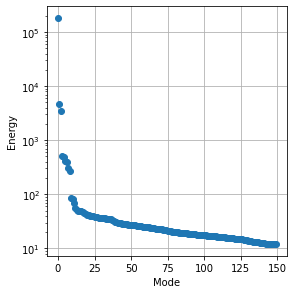

In [9]:

import numpy as np

# Example time series data (rows: time points, columns: features)
time_series_data = u
print(time_series_data.shape)
# Calculate SVD
U, S, Vt = np.linalg.svd(time_series_data)
print(U.shape)
import matplotlib.pyplot as plt

# Example list data
data = S

# Generate the plot
plt.figure(figsize=(4, 4))
plt.plot(data, 'o')  # 'o' indicates dots

# Set logarithmic scale for y-axis
plt.yscale('log')
#plt.xticks(fontsize=tick_fontsize,fontweight='bold')
#plt.yticks(fontsize=tick_fontsize,fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()
# Add labels and title
plt.xlabel('Mode')
plt.ylabel('Energy')

plt.grid(True)
#plt.savefig("POD_modes_S_value.png")
# Display the plot
plt.show()

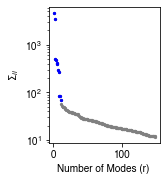

In [10]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Generate the plot
plt.figure(figsize=(2, 2.5))
modes = np.arange(0, len(data), 1)
plt.scatter(modes[1:], data[1:], s=5, color='grey', label='All Modes')
plt.scatter(modes[1:12], data[1:12], s=5, color='blue', label='First 11 Modes')
plt.yscale('log')

plt.xlabel('Number of Modes (r) ', fontproperties=helvetica)
plt.ylabel('$\\Sigma_{ii}$', fontproperties=helvetica)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.savefig("mode_hist/POD_modes_S_value_51.png", bbox_inches='tight', dpi=500)
plt.show()

51
50


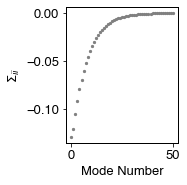

In [40]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

grad_data=np.gradient(data)
print(len(grad_data))
print(len(modes[1:len(data)]))
# Generate the plot
plt.figure(figsize=(2, 2.5))
modes = np.arange(0, len(data), 1)
plt.scatter(modes, grad_data, s=5, color='grey', label='All Modes')
#plt.scatter(modes[1:12], data[1:12], s=5, color='blue', label='First 11 Modes')
#plt.yscale('log')

plt.xlabel('Mode Number', fontproperties=helvetica)
plt.ylabel('$\\Sigma_{ii}$', fontproperties=helvetica)

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.savefig("mode_hist/POD_modes_S_value_51.png", bbox_inches='tight', dpi=500)
plt.show()

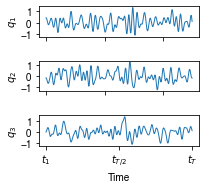

In [11]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

def fourier_lowest_modes(signal, num_modes=None, freq_threshold=None):
   
    num_time_points = len(signal)

    # Compute FFT
    fft_values = np.fft.fft(signal)
    freqs = np.fft.fftfreq(num_time_points)

    # Choose frequency modes
    if num_modes is not None:
        sorted_indices = np.argsort(np.abs(freqs))
        keep_indices = sorted_indices[:num_modes]
    elif freq_threshold is not None:
        keep_indices = np.where(np.abs(freqs) <= freq_threshold)[0]
    else:
        raise ValueError("Either num_modes or freq_threshold must be specified")

    # Truncate FFT
    truncated_fft = np.zeros_like(fft_values, dtype=complex)
    truncated_fft[keep_indices] = fft_values[keep_indices]

    # Reconstruct signal
    reconstructed_signal = np.fft.ifft(truncated_fft).real

    return np.array(reconstructed_signal)

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

# Adjust these parameters to control spacing
left = 0.23
bottom = 0.18
right = 0.95
top = 0.95
hspace = 0.8

fig = plt.figure(figsize=(3.1, 3.5))
plt.subplots_adjust(hspace=hspace, top=top, bottom=bottom, left=left, right=right)

for i in range(1, 4):
    x = Vt[i, :]
    ax = plt.subplot(4, 1, i + 1)
    x = fourier_lowest_modes(x, num_modes=3000)
    plt.plot(x[:500] / np.max(x[:200]), linewidth=1)
    plt.ylabel(f'$q_{i}$', labelpad=1, fontproperties=helvetica)
    plt.yticks(fontsize=9)
    
    if i < 3:
        ax.set_xticklabels([])
    else:
        # Set custom tick positions and labels
        T = len(x[:500])
        ax.set_xticks([0, T//2, T-1])
        ax.set_xticklabels(['$t_1$', '$t_{T/2}$', '$t_T$'], fontproperties=helvetica)
        plt.tick_params(axis='both', which='major')
        plt.xlabel('Time', fontproperties=helvetica)

    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

plt.savefig("mode_hist/time_modes.png", dpi=500, bbox_inches='tight')
plt.show()

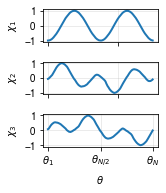

In [12]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import numpy as np

# Set Helvetica font
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

ri = 7
Ur = U[:, 1:ri]
Sr = np.diag(S[1:ri])
Vtr = Vt[1:ri, :]
reconstructed_u = np.dot(Ur, np.dot(Sr, Vtr))
truncated_h = reconstructed_u.T

fig = plt.figure(figsize=(2, 3.1))
plt.subplots_adjust(hspace=0.6, wspace=0.3, left=0.15, bottom=0.1, right=0.95, top=0.95)

for i in range(1, 4):
    ax = plt.subplot(4, 1, i+1)
    plt.plot(Ur[:, i]/np.max(Ur[:, i]), linewidth=2)
    plt.ylabel(f'$\chi_{i}$', labelpad=5, fontproperties=helvetica)
    plt.yticks(fontsize=10)
    if i < 3:
        ax.set_xticklabels([])
    else:
        plt.xlabel(r'$\theta$', labelpad=5, fontproperties=helvetica)
        N = len(Ur[:, i])
        ax.set_xticks([0, N//2, N-1])
        ax.set_xticklabels([r'$\theta_1$', r'$\theta_{N/2}$', r'$\theta_N$'], fontproperties=helvetica)
    plt.grid(True, alpha=0.3)
    # Set tick labels to Helvetica
    for label in ax.get_xticklabels():
        label.set_fontproperties(helvetica)
    for label in ax.get_yticklabels():
        label.set_fontproperties(helvetica)

plt.savefig("mode_hist/space_modes_plot.png", dpi=500, bbox_inches='tight')
plt.show()

<Figure size 432x360 with 0 Axes>

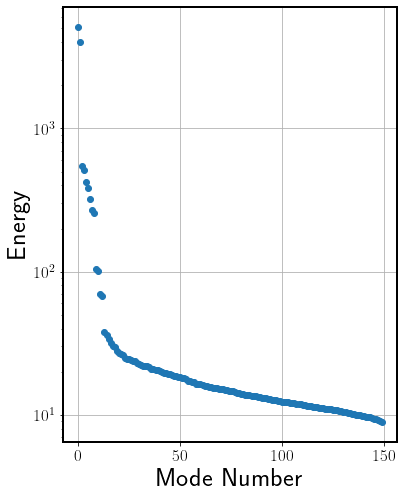

In [75]:
import mpld3
%matplotlib inline
mpld3.enable_notebook()
from scipy.stats import gaussian_kde
    
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
import numpy as np
from numpy import loadtxt
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d

matplotlib.rcParams['text.usetex'] = True


plt.rcParams['axes.labelweight'] = 'bold'
rc = {'axes.labelsize': 27, 
      'axes.linewidth': 2.0,
      'font.size': 20,
      'legend.fontsize': 20}
plt.rcParams.update(**rc)



def read_floats_from_file(filename):

    floats = []
    with open(filename, 'r') as file:
        for line in file:
            floats.append(float(line.strip())) 
    return floats





plt.figure(figsize=(6, 5))  # Larger figure for better visibility

# Set font sizes
title_fontsize = 16
label_fontsize = 26
legend_fontsize = 10
tick_fontsize = 17
scale=[0.09882452025988064,0.24106443376664843,0.3677247244563667]

plt.figure(figsize=(6, 8))
plt.plot(data, 'o')  # 'o' indicates dots

# Set logarithmic scale for y-axis
plt.yscale('log')
plt.xticks(fontsize=tick_fontsize,fontweight='bold')
plt.yticks(fontsize=tick_fontsize,fontweight='bold')

# Add labels and title
plt.xlabel('Mode Number',fontsize=label_fontsize)
plt.ylabel('Energy',fontsize=label_fontsize)
#plt.title('Logarithmic Y-Axis Plot with Dots')
plt.grid(True)
plt.savefig("POD_modes_S_value.png",dpi=500)
plt.show()




(150, 25175)


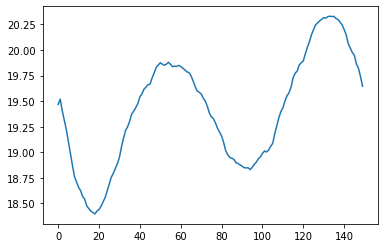

In [17]:
ri=6
Ur = U[:, :ri]
Sr = np.diag(S[:ri])
Vtr = Vt[:ri, :]
reconstructed_u = np.dot(Ur, np.dot(Sr, Vtr))

truncated_h=reconstructed_u.T
print(reconstructed_u.shape)
plt.plot(truncated_h[1,:])

In [46]:
ri=1
Ur = U[:, :ri]
Sr = np.diag(S[:ri])
Vtr = Vt[:ri, :]
reconstructed1_u = np.dot(Ur, np.dot(Sr, Vtr))
truncated_h=reconstructed_u.T
print(truncated_h.shape)

(6000, 150)


In [74]:
import matplotlib
matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
import numpy as np
from numpy import loadtxt
from scipy.stats import gaussian_kde
from scipy.interpolate import interp1d
import os
from matplotlib.ticker import MultipleLocator

plt.rcParams['axes.labelweight'] = 'bold'
rc = {'axes.labelsize': 35, 
      'axes.linewidth': 2.0,
      'font.size': 20,
      'legend.fontsize': 20}
plt.rcParams.update(rc)

# Create directory to save plots if it doesn't exist
output_folder = "mode_plots"
os.makedirs(output_folder, exist_ok=True)

ri = 4
Ur = U[:, :ri]
Sr = np.diag(S[:ri])
Vtr = Vt[:ri, :]

# Assuming thetas is your x-axis data ranging from 0 to 2π
thetas = np.linspace(0, 2*np.pi, len(U[:, 0]))  # Create theta values if not already defined

for t in range(0, 2):
    fig = plt.figure(figsize=(4, 8))
    
    # Adjust subplot spacing parameters
    plt.subplots_adjust(hspace=0.05,  # Reduced vertical space between subplots
                       left=0.15,    # Left margin
                       right=0.95,   # Right margin
                       top=0.97,     # Top margin
                       bottom=0.08)  # Slightly increased bottom margin
    
    for r in range(ri):
        ax = plt.subplot(ri, 1, r+1)
        mode_temp = U[:, r] * Vt[r, t]
        normalized_mode = mode_temp/np.max(np.abs(mode_temp))
        
        ax.plot(thetas, normalized_mode, linewidth=4)
        ax.set_ylim(-1.2, 1.2)
        ax.set_ylabel(f"$\chi_{r+1}$", fontsize=31,fontweight='bold')
        
        # Set x-axis limits and ticks
        ax.set_xlim(0, 2*np.pi)
        
        # Customize x-ticks for all plots (but only show labels on bottom)
        ax.xaxis.set_major_locator(MultipleLocator(base=np.pi/2))
        ax.tick_params(axis='x', which='major', length=8, width=2)
        
        if r < ri-1:
            ax.set_xticklabels([])
        else:
            # Format x-tick labels with π symbols on bottom plot
            ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
            ax.set_xticklabels(['$0$', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'], 
                              fontsize=25)
            ax.set_xlabel(r'$\theta$', fontsize=31,fontweight='bold')  # Changed from "Spatial index"
        
        # Customize y-ticks
        ax.set_yticks([-1, 0, 1])
        ax.tick_params(axis='y', labelsize=25)
        
        # Add grid
        ax.grid(True, linestyle='--', alpha=0.6)
    
    # Save the figure for this time step
    filename = os.path.join(output_folder, f"modes_at_t_{t:02d}.png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()

print(f"All plots saved in '{output_folder}' directory")

All plots saved in 'mode_plots' directory


In [14]:
ri=5
Ur = U[:, :ri]
Sr = np.diag(S[:ri])
Vtr = Vt[:ri, :]
reconstructed5_u = np.dot(Ur, np.dot(Sr, Vtr))
truncated_h=reconstructed5_u.T
print(truncated_h.shape)

(25175, 150)


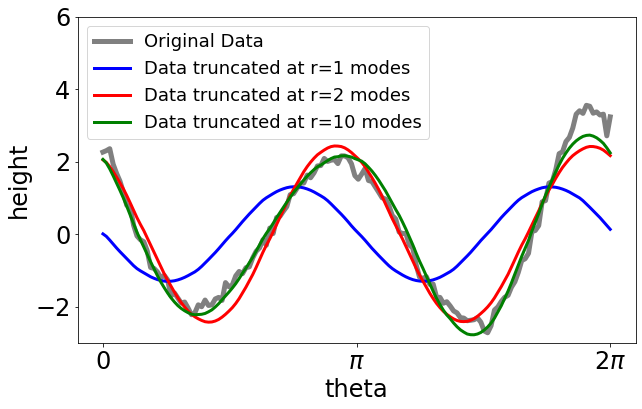

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FuncFormatter
from scipy.interpolate import interp1d

plt.rcParams.update({'font.size': 24})  # Main font size
plt.figure(figsize=(10,6))
plt.plot(thetas, u[:,0], color='grey', label="Original Data", linewidth=5)
plt.plot(thetas, reconstructed1_u[:,0], color="blue", label="Data truncated at r=1 modes", linewidth=3)
plt.plot(thetas, reconstructed_u[:,0], color="red", label="Data truncated at r=2 modes", linewidth=3)
plt.plot(thetas, reconstructed5_u[:,0], color="green", label="Data truncated at r=10 modes", linewidth=3)

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(base=np.pi))
ax.xaxis.set_major_formatter(FuncFormatter(format_func))

# Modified legend command with fontsize parameter
plt.legend(fontsize=18)  # Reduced from 24 to 18 (adjust as needed)

plt.xlabel("theta")
plt.ylabel("height")
plt.ylim(-3,6)
plt.savefig("error_H_mode.png", dpi=300)
plt.show()


In [26]:
error_list=[]
for r in range(1,20):
    ri=r
    Ur = U[:, :ri]
    Sr = np.diag(S[:ri])
    Vtr = Vt[:ri, :]
    reconstructed_u = np.dot(Ur, np.dot(Sr, Vtr))
    
    error=np.mean(np.abs((reconstructed_u[:,0]-u[:,0])/u[:,0]))
    print(error)
    error_list.append(error)
    

0.013499187269236457
0.002284410302480241
0.0020173531980767424
0.0019942226871849738
0.0019505089657908114
0.0019358828282307317
0.0019137239647958112
0.0013193339673828281
0.0008691764131401644
0.0008231761408497715
0.0008071447713133313
0.0008049721935828404
0.0008067248494776275
0.0008111692599211017
0.0008112952270759524
0.0008095844049399628
0.0007981345052342686
0.0007977107382211878
0.0007647765191789443


findfont: Font family ['Helvetica'] not found. Falling back to DejaVu Sans.


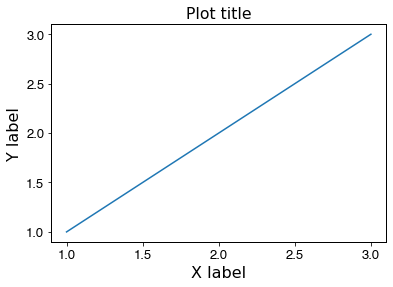

In [31]:
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import matplotlib

import matplotlib.pyplot as plt
import numpy as np
from numpy import loadtxt
import os
rc = {
    'axes.labelsize': 16,
    'axes.linewidth': 1.0,
    'font.size': 13,
    'legend.fontsize': 12,
}
plt.rcParams.update(rc)

helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

fig, ax = plt.subplots()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)
ax.plot([1, 2, 3], [1, 2, 3])
ax.set_xlabel('X label')
ax.set_ylabel('Y label')
ax.set_title('Plot title')
plt.show()


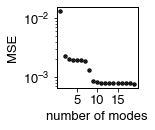

In [62]:
from matplotlib import pyplot as plt
from matplotlib.font_manager import FontProperties

# Load Helvetica font properties
helvetica = FontProperties(fname='/home/samuel/Documents/fonts_hel/Helvetica.ttf')
plt.rcParams['font.family'] = helvetica.get_name()

plt.figure(figsize=(2.2, 2.))
modes1=np.arange(1, len(error_list)+1, 1)
plt.scatter(modes1,error_list, color="black", s=2,linewidth=3)

plt.xlabel("number of modes", fontproperties=helvetica)
plt.ylabel("MSE", fontproperties=helvetica)
plt.yscale('log')

ax = plt.gca()
for label in ax.get_xticklabels():
    label.set_fontproperties(helvetica)
for label in ax.get_yticklabels():
    label.set_fontproperties(helvetica)

plt.tight_layout()
plt.savefig("mode_hist/error_in_modes", bbox_inches='tight', dpi=300)
plt.show()


In [ ]:
import numpy as np

# Example time series data (rows: time points, columns: features)
time_series_data = u
print(time_series_data.shape)
# Calculate SVD
U, S, Vt = np.linalg.svd(time_series_data)
print(U.shape)
import matplotlib.pyplot as plt

# Example list data
data = S

# Generate the plot
plt.figure(figsize=(8, 6))
plt.plot(data, 'o')  # 'o' indicates dots

# Set logarithmic scale for y-axis
plt.yscale('log')
plt.xticks(fontsize=tick_fontsize,fontweight='bold')
plt.yticks(fontsize=tick_fontsize,fontweight='bold')

# Adjust layout to prevent overlap
plt.tight_layout()
# Add labels and title
plt.xlabel('Mode')
plt.ylabel('Energy')

plt.grid(True)
plt.savefig("POD_modes_S_value.png")
# Display the plot
plt.show()

(150, 25175)


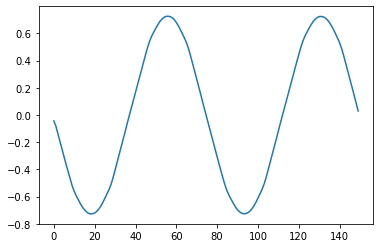

(150, 17553)


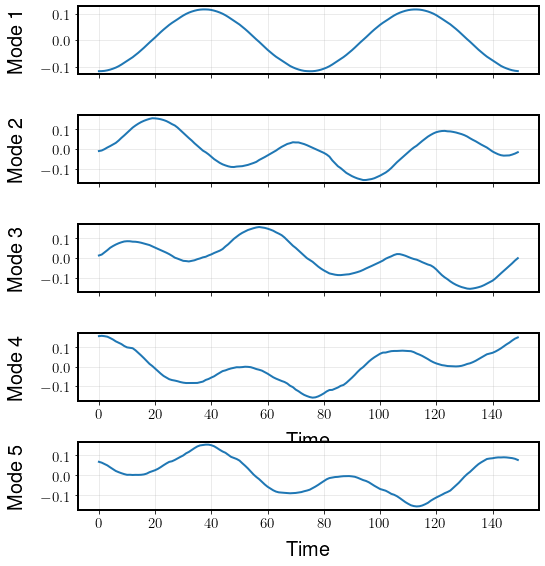

In [80]:
import matplotlib.pyplot as plt
import numpy as np
ri=7
Ur = U[:, 1:ri]
Sr = np.diag(S[1:ri])
Vtr = Vt[1:ri, :]
reconstructed_u = np.dot(Ur, np.dot(Sr, Vtr))

truncated_h=reconstructed_u.T
print(reconstructed_u.shape)

# Set up the figure with your preferred style
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams.update({
    'axes.labelsize': 20,
    'axes.linewidth': 2.0,
    'font.size': 15,
    'legend.fontsize': 16
})

# Create figure with adjusted layout
fig = plt.figure(figsize=(8, 10))  # Increased size for better visibility
plt.subplots_adjust(hspace=0.6, wspace=0.3,  # Increased spacing
                   left=0.15, bottom=0.1, 
                   right=0.95, top=0.95)

# Plot each mode as a subplot
for i in range(1,6):  # For columns 1-5 (Python uses 0-based indexing)
    ax = plt.subplot(6, 1, i+1)
    
    # Plot the mode (Ur[:,i] for column i)
    plt.plot(Ur[:,i], linewidth=2)
    
    # Add labels with proper formatting
    plt.ylabel(f'Mode {i}', labelpad=15)
    
    # Only show x-axis label on bottom plot
    if i < 4:
        ax.set_xticklabels([])
    else:
        plt.xlabel('Time', labelpad=10)
    
    # Add grid for better readability
    plt.grid(True, alpha=0.3)

plt.savefig("modes_plot.png", dpi=500, bbox_inches='tight')
plt.show()